# ML niveau 1 — EDA, feature engineering et Random Forest

Ce notebook présente le raisonnement complet : comprendre le dataset français,
contrôler sa qualité, formuler des hypothèses de variables, créer ces variables,
puis entraîner et évaluer une forêt aléatoire.

In [21]:
# Gestion des annotations de type pour compatibilité avec les versions antérieures de Python
from __future__ import annotations

# Importations des bibliothèques standard
import argparse # Pour gérer les arguments de la ligne de commande
import json # Pour la sérialisation des métriques en JSON
from pathlib import Path # Pour gérer les chemins de fichiers de manière indépendante du système d'exploitation

In [22]:
# Importations tierces
import joblib # Pour la sérialisation du modèle entraîné - Sauvegarde du pipeline de machine learning
import pandas as pd # Pour la manipulation des données - Lire CSV et gérer les DataFrames,

# Import seulement un élément pour le prétraitement des données - Sklearn fournit des outils pour diviser les données, transformer les colonnes, gérer les valeurs manquantes, encoder les variables catégorielles, normaliser les variables numériques, entraîner un modèle de forêt aléatoire et évaluer ses performances.
from sklearn.model_selection import train_test_split # Pour diviser le dataset en ensembles d'entraînement et de test
from sklearn.compose import ColumnTransformer # Pour appliquer différentes transformations à différentes colonnes du DataFrame
from sklearn.impute import SimpleImputer # Pour gérer les valeurs manquantes dans les données
from sklearn.preprocessing import OneHotEncoder # Pour encoder les variables catégorielles ou textuelles en format numérique
from sklearn.preprocessing import StandardScaler # Normaliser les variables numériques
from sklearn.ensemble import RandomForestClassifier # Pour entraîner un modèle de forêt aléatoire pour la classification et Prédiction
from sklearn.metrics import classification_report, confusion_matrix, f1_score # Pour évaluer les performances du modèle - Générer un rapport de classification, une matrice de confusion et calculer le score F1
from sklearn.pipeline import Pipeline # Pour créer un pipeline de machine learning qui enchaîne les étapes de prétraitement et d'entraînement du modèle

In [26]:
# Définition des constantes pour le traitement des données
CIBLE = "gravite" # La variable cible que le modèle doit prédire
VARIABLES_CATEGORIELLES = ["categorie", "nom_source"] # Les colonnes textuelles qui seront transformées en variables numériques avec OneHotEncoder
# Définition des colonnes numériques du dataset qui seront normalisées pour l'entraînement du modèle
VARIABLES_NUMERIQUES = [
    "annee_survenue", "annee_publication", "longueur_titre",
    "nombre_developpeurs", "nombre_deployeurs",
    "nombre_parties_lesees", "nombre_etiquettes",
]

COLONNES_REQUISES = {
    "identifiant", "titre", "date_survenue", "date_publication",
    "nom_source", "categorie", "gravite", "developpeurs", "deployeurs",
    "parties_lesees", "etiquettes",
}

In [28]:
# Fonctions utilitaires pour le traitement des données et l'entraînement du modèle
def compter_elements(value: object) -> int:

    # Compte les éléments des listes JSON et des textes séparés par une barre verticale.
    if pd.isna(value) or not str(value).strip():
        return 0
    texte = str(value).strip()
    # On essaie de charger le texte comme une liste JSON. Si cela échoue, on suppose que le texte est une chaîne de caractères séparée par des barres verticales et on le divise en éléments.
    try:
        elements = json.loads(texte)
    except json.JSONDecodeError:
        elements = [element.strip() for element in texte.split("|")]
    if not isinstance(elements, list):
        elements = [elements]
    return len([element for element in elements if str(element).strip()])

In [30]:
# Fonction pour préparer le dataset avant l'entraînement du modèle
def preparer_dataset(chemin: Path) -> pd.DataFrame:

    # Crée des variables simples sans employer les champs qui révèlent la cible.
    donnees = pd.read_csv(chemin)
    donnees = donnees.drop_duplicates(subset=["identifiant"]).copy()
    colonnes_absentes = sorted(COLONNES_REQUISES - set(donnees.columns))

    # Si des colonnes requises sont manquantes, lève une exception avec un message d'erreur indiquant quelles colonnes sont absentes
    if colonnes_absentes:
        raise ValueError(f"Colonnes absentes : {colonnes_absentes}")
    for source, output in (
        ("date_survenue", "annee_survenue"),
        ("date_publication", "annee_publication"),
    ):
        donnees[output] = pd.to_datetime(donnees[source], errors="coerce").dt.year # Convertit les colonnes de date en années et gère les erreurs de conversion
    donnees["longueur_titre"] = donnees["titre"].fillna("").str.len()

    # Crée de nouvelles colonnes pour compter les éléments des listes : développeurs, déployeurs, parties lésées et étiquettes.
    for source, output in (
        ("developpeurs", "nombre_developpeurs"),
        ("deployeurs", "nombre_deployeurs"),
        ("parties_lesees", "nombre_parties_lesees"),
        ("etiquettes", "nombre_etiquettes"),
    ):
        donnees[output] = donnees[source].map(compter_elements)

    # Sélectionne les colonnes pertinentes et supprime les lignes dont la gravité est absente.
    colonnes = VARIABLES_CATEGORIELLES + VARIABLES_NUMERIQUES + [CIBLE]

    # Prépare le DataFrame final en sélectionnant les colonnes pertinentes et en gérant les valeurs manquantes
    donnees_preparees = donnees[colonnes].dropna(subset=[CIBLE]).copy()
    for colonne in VARIABLES_CATEGORIELLES:
        donnees_preparees[colonne] = donnees_preparees[colonne].fillna("non renseigné").astype(str)
    return donnees_preparees

In [31]:
# Fonction pour construire le pipeline de machine learning
def construire_pipeline() -> Pipeline:

    # Réunit la préparation des variables et le Random Forest
    preprocessor = ColumnTransformer(
        [
            (
                "categories",
                Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore"))]), # Pipeline pour gérer les colonnes catégorielles : imputation des valeurs manquantes avec la valeur la plus fréquente, puis encodage OneHot pour transformer les catégories en variables binaires
                VARIABLES_CATEGORIELLES,
            ),
            (
                "nombres",
                Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), # Pipeline pour gérer les colonnes numériques : imputation des valeurs manquantes avec la médiane, puis normalisation des variables numériques
                VARIABLES_NUMERIQUES,
            ),
        ]
    )

    # Définition du modèle de forêt aléatoire avec des paramètres spécifiques pour l'entraînement
    model = RandomForestClassifier(
        n_estimators=200, min_samples_leaf=2, class_weight="balanced", # Utilise un nombre d'arbres de 200, une taille minimale de feuille de 2 et un poids de classe équilibré pour gérer les classes déséquilibrées dans le dataset
        random_state=42, n_jobs=-1, # Utilise un état aléatoire fixe pour la reproductibilité et utilise tous les cœurs disponibles pour l'entraînement du modèle
    )
    return Pipeline([("preparation", preprocessor), ("modele", model)]) # Crée un pipeline final qui combine le préprocesseur et le modèle de forêt aléatoire pour l'entraînement et la prédiction

In [32]:
# Fonction principale pour exécuter l'entraînement, l'évaluation et la sauvegarde des résultats
def executer(jeu_donnees: Path, repertoire_sortie: Path) -> None:

    # Entraîne, évalue et sauvegarde les résultats essentiels
    donnees = preparer_dataset(jeu_donnees)

    # Sépare les données en ensembles d'entraînement et de test, en stratifiant par la variable cible pour maintenir la distribution des classes
    x, y = donnees.drop(columns=CIBLE), donnees[CIBLE]
    x_entrainement, x_evaluation, y_entrainement, y_evaluation = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y # Utilise 20% des données pour le test, un état aléatoire fixe pour la reproductibilité et stratifie par la variable cible pour maintenir la distribution des classes
    )

    # Construit le pipeline de machine learning en combinant le prétraitement des données et le modèle de forêt aléatoire
    pipeline = construire_pipeline()

    # Entraîne le pipeline sur les données d'entraînement et effectue des prédictions sur les données de test
    pipeline.fit(x_entrainement, y_entrainement)

    # Effectue des prédictions sur l'ensemble de test pour évaluer les performances du modèle
    predictions = pipeline.predict(x_evaluation)
    repertoire_sortie.mkdir(parents=True, exist_ok=True) # Crée le répertoire de sortie s'il n'existe pas déjà

    # Sauvegarde le pipeline entraîné, les métriques d'évaluation et la matrice de confusion dans le répertoire de sortie spécifié
    joblib.dump(pipeline, repertoire_sortie / "foret_aleatoire_incidents_ia.joblib")
    metriques = {
        "nombre_exemples": len(donnees),
        "nombre_exemples_evaluation": len(y_evaluation),
        "f1_macro": float(f1_score(y_evaluation, predictions, average="macro")),
    }
    # Sauvegarde les métriques d'évaluation dans un fichier JSON et le rapport de classification dans un fichier texte
    (repertoire_sortie / "metriques.json").write_text(
        json.dumps(metriques, indent=2, ensure_ascii=False), encoding="utf-8"
    )
    # Sauvegarde le rapport de classification dans un fichier texte pour une analyse plus détaillée des performances du modèle sur chaque classe
    (repertoire_sortie / "rapport_classification.txt").write_text(
        classification_report(y_evaluation, predictions, zero_division=0), encoding="utf-8"
    )
    classes = sorted(y.unique())

    # Sauvegarde la matrice de confusion dans un fichier CSV pour visualiser les performances du modèle sur chaque classe
    pd.DataFrame(
        confusion_matrix(y_evaluation, predictions, labels=classes),
        index=[f"reel_{classe}" for classe in classes],
        columns=[f"predit_{classe}" for classe in classes],
    ).to_csv(repertoire_sortie / "matrice_confusion.csv")

    # Affiche les métriques d'évaluation dans la console pour un retour immédiat sur les performances du modèle
    print(json.dumps(metriques, indent=2, ensure_ascii=False))

In [33]:
# Fonction utilitaire pour trouver le dataset par défaut
def jeu_donnees_par_defaut() -> Path:
    # Dans Jupyter, __file__ n'existe pas : recherche depuis le dossier courant.
    dossier_courant = Path.cwd()
    candidats = (
        dossier_courant / "../datasets/ml/ai_incidents_fr.csv",
        dossier_courant / "notebooks/datasets/ml/ai_incidents_fr.csv",
        dossier_courant / "datasets/ml/ai_incidents_fr.csv",
    )
    return next(chemin.resolve() for chemin in candidats if chemin.exists())


def repertoire_sortie_par_defaut() -> Path:
    # Remonte depuis le dataset pour retrouver la racine du dépôt PoC.
    racine_projet = jeu_donnees_par_defaut().parents[3]
    return racine_projet / "outputs/incidents_ia"

## 1. Charger et examiner le dataset français

L'analyse exploratoire des données, ou **EDA**, intervient avant l'entraînement.
Elle sert à connaître la taille du dataset, ses colonnes, les valeurs manquantes,
les doublons et la distribution de la cible.

In [34]:
import matplotlib.pyplot as plt

chemin_dataset = jeu_donnees_par_defaut()
donnees_brutes = pd.read_csv(chemin_dataset)

print(f"Nombre de lignes : {len(donnees_brutes)}")
print(f"Nombre de colonnes : {len(donnees_brutes.columns)}")
print(f"Nombre de doublons d'identifiant : {donnees_brutes['identifiant'].duplicated().sum()}")
donnees_brutes.head(3)

Nombre de lignes : 6865
Nombre de colonnes : 11
Nombre de doublons d'identifiant : 0


,identifiant,titre,date_survenue,date_publication,nom_source,categorie,gravite,developpeurs,deployeurs,parties_lesees,etiquettes
0,cmth6s07x00e0p301ij6u6iie,La théorie du changement : la mise en pratique,2026-08-31T10:51:46.000Z,2026-08-31T10:51:46.000Z,AI Alignment Forum,LLM,FAIBLE,NaN,NaN,NaN,[]
1,cmtgtxzed00dup301lj0n3uiu,Le crédit marginal réduit l'exploration redond...,2026-08-27T06:24:03.000Z,2026-08-27T06:24:03.000Z,arXiv,LLM,FAIBLE,NaN,NaN,NaN,[]
2,cmtgtxy1i00dtp301jg019mwn,Plus de données ne peuvent pas briser une symm...,2026-08-27T19:38:09.000Z,2026-08-27T19:38:09.000Z,arXiv,LLM,FAIBLE,NaN,NaN,NaN,[]


## 2. Contrôler la qualité des données

Pour chaque colonne, nous observons son type, son nombre de valeurs manquantes
et son nombre de valeurs différentes. Ce contrôle permet de décider si une
variable est exploitable et quel traitement lui appliquer.

In [35]:
qualite = pd.DataFrame(
    {
        "type": donnees_brutes.dtypes.astype(str),
        "valeurs_manquantes": donnees_brutes.isna().sum(),
        "proportion_manquante": donnees_brutes.isna().mean().round(3),
        "valeurs_uniques": donnees_brutes.nunique(dropna=True),
    }
)
qualite

,type,valeurs_manquantes,proportion_manquante,valeurs_uniques
identifiant,object,0,0.000,6865
titre,object,0,0.000,6853
date_survenue,object,0,0.000,5676
date_publication,object,59,0.009,5594
nom_source,object,0,0.000,20
categorie,object,0,0.000,11
gravite,object,0,0.000,4
developpeurs,object,5209,0.759,642
deployeurs,object,5152,0.750,1223
parties_lesees,object,5210,0.759,1580


## 3. Étudier la variable cible

La cible est déséquilibrée : `CRITIQUE` est beaucoup plus rare que `FAIBLE`.
Cette observation justifie `stratify=y`, `class_weight="balanced"` et le choix
du macro-F1 comme métrique principale.

In [36]:
distribution_gravite = (
    donnees_brutes["gravite"]
    .value_counts()
    .rename_axis("gravite")
    .reset_index(name="nombre")
)
distribution_gravite["proportion"] = (
    distribution_gravite["nombre"] / len(donnees_brutes)
).round(3)
distribution_gravite

,gravite,nombre,proportion
0,FAIBLE,3250,0.473
1,MOYENNE,2261,0.329
2,ELEVEE,1275,0.186
3,CRITIQUE,79,0.012


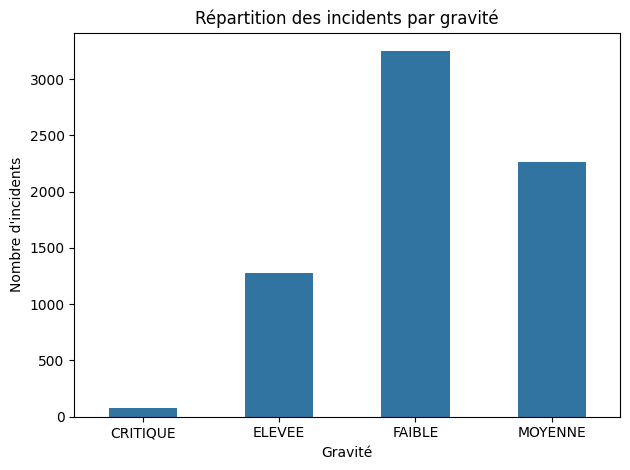

In [37]:
axes = donnees_brutes["gravite"].value_counts().sort_index().plot.bar(
    color="#3274a1",
    title="Répartition des incidents par gravité",
)
axes.set_xlabel("Gravité")
axes.set_ylabel("Nombre d'incidents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Examiner les catégories disponibles

`categorie` et `nom_source` sont conservées comme variables catégorielles.
Le pipeline les transformera ensuite avec `OneHotEncoder`.

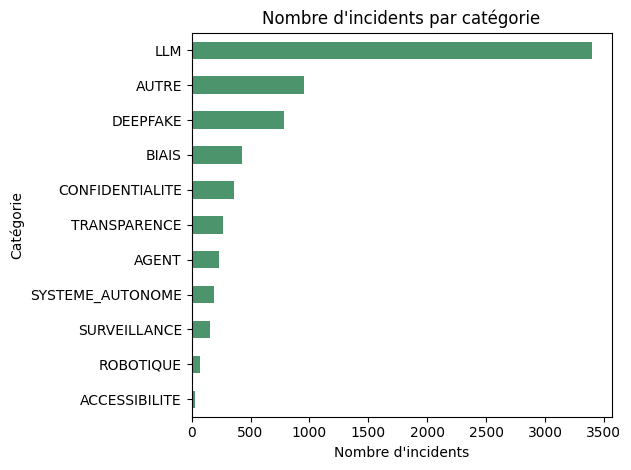

In [38]:
donnees_brutes["categorie"].value_counts().sort_values().plot.barh(
    color="#4c956c",
    title="Nombre d'incidents par catégorie",
)
plt.xlabel("Nombre d'incidents")
plt.ylabel("Catégorie")
plt.tight_layout()
plt.show()

## 5. Déterminer les nouvelles variables : feature engineering

Le **feature engineering** consiste à transformer les colonnes brutes en
informations plus simples que le modèle peut exploiter. Chaque transformation
correspond à une hypothèse qui devra ensuite être vérifiée expérimentalement.

In [39]:
choix_variables = pd.DataFrame(
    [
        ["date_survenue", "annee_survenue", "Tester une évolution temporelle des incidents"],
        ["date_publication", "annee_publication", "Mesurer la période de publication"],
        ["titre", "longueur_titre", "Utiliser une propriété simple du texte sans analyser son sens"],
        ["developpeurs", "nombre_developpeurs", "Mesurer combien d'acteurs développent le système"],
        ["deployeurs", "nombre_deployeurs", "Mesurer combien d'acteurs le déploient"],
        ["parties_lesees", "nombre_parties_lesees", "Approcher l'étendue des parties touchées"],
        ["etiquettes", "nombre_etiquettes", "Mesurer combien de thèmes décrivent l'incident"],
        ["categorie", "categorie", "Conserver le type métier de l'incident"],
        ["nom_source", "nom_source", "Conserver l'origine de l'information"],
    ],
    columns=["colonne_originale", "variable_creee", "hypothese"],
)
choix_variables

,colonne_originale,variable_creee,hypothese
0,date_survenue,annee_survenue,Tester une évolution temporelle des incidents
1,date_publication,annee_publication,Mesurer la période de publication
2,titre,longueur_titre,Utiliser une propriété simple du texte sans an...
3,developpeurs,nombre_developpeurs,Mesurer combien d'acteurs développent le système
4,deployeurs,nombre_deployeurs,Mesurer combien d'acteurs le déploient
5,parties_lesees,nombre_parties_lesees,Approcher l'étendue des parties touchées
6,etiquettes,nombre_etiquettes,Mesurer combien de thèmes décrivent l'incident
7,categorie,categorie,Conserver le type métier de l'incident
8,nom_source,nom_source,Conserver l'origine de l'information


Les identifiants sont exclus car ils ne décrivent pas la gravité. La colonne
`gravite` est séparée des entrées, car elle constitue la réponse à prédire.
Donner la cible au modèle provoquerait une fuite de données.

## 6. Voir concrètement les transformations

Le tableau suivant compare quelques valeurs brutes avec les variables produites
par `preparer_dataset`. Les nouvelles variables existent en mémoire ; elles ne
sont pas ajoutées au CSV original.

In [40]:
donnees_preparees_eda = preparer_dataset(chemin_dataset)
index_exemples = donnees_brutes.loc[
    donnees_brutes["developpeurs"].notna() | donnees_brutes["etiquettes"].ne("[]")
].index[:5]

avant = donnees_brutes.loc[
    index_exemples,
    [
        "titre",
        "date_survenue",
        "developpeurs",
        "deployeurs",
        "parties_lesees",
        "etiquettes",
        "gravite",
    ],
]
apres = donnees_preparees_eda.loc[
    index_exemples,
    [
        "annee_survenue",
        "longueur_titre",
        "nombre_developpeurs",
        "nombre_deployeurs",
        "nombre_parties_lesees",
        "nombre_etiquettes",
    ],
]
pd.concat({"avant": avant, "apres": apres}, axis=1)

avant  \
                                                titre   
22  Article généré par l'IA Faux-dépôts Australian...   
23  Oura Smart Ring Acheteur en Californie Société...   
24  Minnesota procureur déclaré utilisé AI-Generat...   
31  Aurora Ransomware Operator Agent de cursure ay...   
32  Pizza Hut Franchisee Chaac Pizza Système AI de...   

                              \
               date_survenue   
22  2026-08-17T00:00:00.000Z   
23  2026-05-22T00:00:00.000Z   
24  2025-08-21T00:00:00.000Z   
31  2026-04-08T00:00:00.000Z   
32  2026-05-06T00:00:00.000Z   

                                                       \
                                         developpeurs   
22  Synthetic media generation technology develope...   
23  Wearable health technology developers | Oura |...   
24                    Large language model developers   
31  Large language model developers | Anysphere | ...   
32  Software developers | Dragontail Systems Limit...   

                                                       \
                                           deployeurs   
22  Synthetic media creators | Scammers in Austral...   
23                                               Oura   
24                          Lawyers | Faisal S. Ahmed   
31  Ransomware operators | Cybercriminals | Aurora...   
32  Restaurants | Pizza Hut | Companies | Chaac Pi...   

                                                                             \
                                       parties_lesees   etiquettes  gravite   
22  Victims of impersonation scams | Michele Bullo...  ["Réponse"]   ELEVEE   
23       Oura Ring users | Madison Surber | Consumers  ["Réponse"]  MOYENNE   
24  Judicial integrity | Hennepin County District ...           []   ELEVEE   
31  Teckentrup | Organizations | Helideck Certific...           []   ELEVEE   
32  Restaurants | Pizza Hut | Consumers | Companie...           []   ELEVEE   

            apres                                                       \
   annee_survenue longueur_titre nombre_developpeurs nombre_deployeurs   
22           2026            197                   3                 7   
23           2026            117                   3                 1   
24           2025            131                   1                 2   
31           2026            118                   4                 5   
32           2026            157                   3                 4   

                                            
   nombre_parties_lesees nombre_etiquettes  
22                     8                 1  
23                     3                 1  
24                     5                 0  
31                     6                 0  
32                     5                 0

## 7. Vérifier si les variables semblent varier selon la gravité

Cette comparaison descriptive ne prouve pas une relation causale. Elle permet
seulement de voir si les moyennes diffèrent assez pour justifier un premier essai.

In [41]:
donnees_preparees_eda.groupby("gravite")[VARIABLES_NUMERIQUES].mean().round(2)

,annee_survenue,annee_publication,longueur_titre,nombre_developpeurs,nombre_deployeurs,nombre_parties_lesees,nombre_etiquettes
gravite,,,,,,,
CRITIQUE,2022.08,2023.46,100.66,1.13,1.06,2.29,0.87
ELEVEE,2024.44,2024.86,110.96,0.96,1.22,2.34,1.51
FAIBLE,2025.95,2025.97,100.29,0.01,0.00,0.01,0.13
MOYENNE,2023.98,2024.23,107.08,0.64,0.76,1.47,1.08


## 8. Comparer catégorie et gravité

Un tableau croisé permet d'observer la proportion des gravités à l'intérieur
de chaque catégorie. Il aide à vérifier si `categorie` peut apporter une
information au modèle.

In [42]:
comparaison_categories = pd.crosstab(
    donnees_brutes["categorie"],
    donnees_brutes["gravite"],
    normalize="index",
).round(3)
comparaison_categories

gravite,CRITIQUE,ELEVEE,FAIBLE,MOYENNE
categorie,,,,
ACCESSIBILITE,0.000,0.000,0.519,0.481
AGENT,0.000,0.220,0.470,0.309
AUTRE,0.010,0.034,0.897,0.059
BIAIS,0.007,0.222,0.155,0.616
CONFIDENTIALITE,0.003,0.380,0.177,0.440
DEEPFAKE,0.015,0.544,0.026,0.415
LLM,0.006,0.125,0.549,0.320
ROBOTIQUE,0.054,0.122,0.338,0.486
SURVEILLANCE,0.006,0.400,0.052,0.542


## 9. Comparer trois niveaux de modèle

Cette expérience répond à deux questions :

1. La forêt aléatoire fait-elle mieux qu'un modèle naïf qui prédit toujours la
   classe la plus fréquente ?
2. Les variables créées améliorent-elles le résultat par rapport aux seules
   variables `categorie` et `nom_source` ?

La séparation et la graine sont identiques pour rendre la comparaison juste.

In [43]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

x_complet = donnees_preparees_eda.drop(columns=CIBLE)
y_complet = donnees_preparees_eda[CIBLE]
x_entrainement_cmp, x_evaluation_cmp, y_entrainement_cmp, y_evaluation_cmp = (
    train_test_split(
        x_complet,
        y_complet,
        test_size=0.2,
        random_state=42,
        stratify=y_complet,
    )
)

modele_naif = DummyClassifier(strategy="most_frequent")

preparation_categories = ColumnTransformer(
    [
        (
            "categories",
            OneHotEncoder(handle_unknown="ignore"),
            VARIABLES_CATEGORIELLES,
        )
    ]
)
foret_sans_variables_creees = Pipeline(
    [
        ("preparation", preparation_categories),
        (
            "modele",
            RandomForestClassifier(
                n_estimators=200,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

modeles_comparaison = {
    "Modèle naïf": modele_naif,
    "Forêt sans variables créées": foret_sans_variables_creees,
    "Forêt avec feature engineering": construire_pipeline(),
}

resultats_comparaison = []
for nom, modele_comparaison in modeles_comparaison.items():
    modele_comparaison.fit(x_entrainement_cmp, y_entrainement_cmp)
    predictions_cmp = modele_comparaison.predict(x_evaluation_cmp)
    resultats_comparaison.append(
        {
            "modele": nom,
            "exactitude": accuracy_score(y_evaluation_cmp, predictions_cmp),
            "f1_macro": f1_score(
                y_evaluation_cmp,
                predictions_cmp,
                average="macro",
                zero_division=0,
            ),
        }
    )

comparaison_modeles = (
    pd.DataFrame(resultats_comparaison)
    .sort_values("f1_macro", ascending=False)
    .reset_index(drop=True)
)
comparaison_modeles

,modele,exactitude,f1_macro
0,Forêt avec feature engineering,0.733430,0.551739
1,Forêt sans variables créées,0.667881,0.502813
2,Modèle naïf,0.473416,0.160652


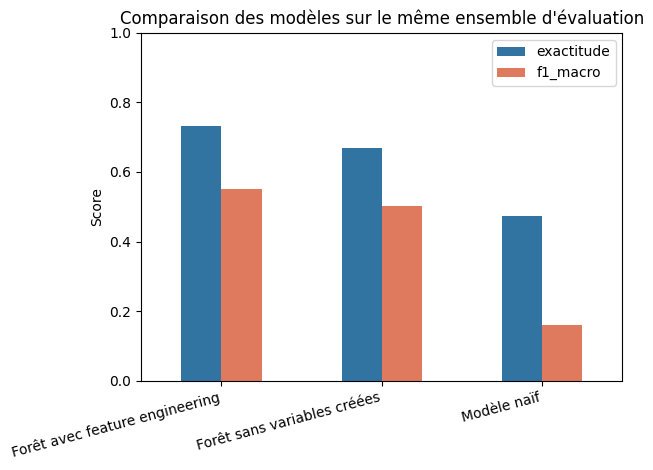

In [44]:
comparaison_modeles.set_index("modele")[["exactitude", "f1_macro"]].plot.bar(
    ylim=(0, 1),
    color=["#3274a1", "#e07a5f"],
    title="Comparaison des modèles sur le même ensemble d'évaluation",
)
plt.ylabel("Score")
plt.xlabel("")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

Si la forêt complète dépasse la forêt sans variables créées, le feature
engineering apporte une information mesurable. Si les scores sont proches ou
inférieurs, certaines variables devront être retirées ou repensées.

## 10. Entraîner et évaluer le pipeline final

Les cellules précédentes expliquent l'origine des variables. La cellule suivante
lance maintenant la séparation 80/20, le prétraitement, l'entraînement des 200
arbres, les prédictions et la sauvegarde des résultats.

In [45]:
# Point d'entrée du notebook
if __name__ == "__main__":
    # Gestion des arguments de la ligne de commande pour spécifier le chemin du dataset et le répertoire de sortie
    parser = argparse.ArgumentParser(description=__doc__)
    # Ajoute un argument pour spécifier le chemin du dataset à utiliser pour l'entraînement et l'évaluation du modèle, avec une valeur par défaut si aucun chemin n'est fourni
    parser.add_argument(
        "--jeu-donnees",
        dest="jeu_donnees",
        type=Path,
        default=jeu_donnees_par_defaut(),
    )
    # Ajoute un argument pour spécifier le répertoire de sortie où les résultats seront sauvegardés, avec une valeur par défaut si aucun répertoire n'est fourni
    parser.add_argument(
        "--repertoire-sortie",
        type=Path,
        default=repertoire_sortie_par_defaut(),
    )
    args = parser.parse_args([])

    # Exécute la fonction principale avec les arguments fournis par l'utilisateur ou les valeurs par défaut
    executer(args.jeu_donnees, args.repertoire_sortie)

{
  "nombre_exemples": 6865,
  "nombre_exemples_evaluation": 1373,
  "f1_macro": 0.5517385650477752
}


## 11. Lire les résultats du modèle final

Une soutenance ne doit pas s'arrêter au score global. Nous affichons la
macro-F1 et la matrice de confusion afin d'identifier les gravités bien ou mal
reconnues.

In [46]:
repertoire_resultats = repertoire_sortie_par_defaut()
metriques_finales = json.loads(
    (repertoire_resultats / "metriques.json").read_text(encoding="utf-8")
)
pd.Series(metriques_finales, name="valeur").to_frame()

,valeur
nombre_exemples,6865.000000
nombre_exemples_evaluation,1373.000000
f1_macro,0.551739


In [47]:
matrice_confusion_finale = pd.read_csv(
    repertoire_resultats / "matrice_confusion.csv",
    index_col=0,
)
matrice_confusion_finale

,predit_CRITIQUE,predit_ELEVEE,predit_FAIBLE,predit_MOYENNE
reel_CRITIQUE,3,8,0,5
reel_ELEVEE,10,168,11,66
reel_FAIBLE,2,6,616,26
reel_MOYENNE,14,115,103,220


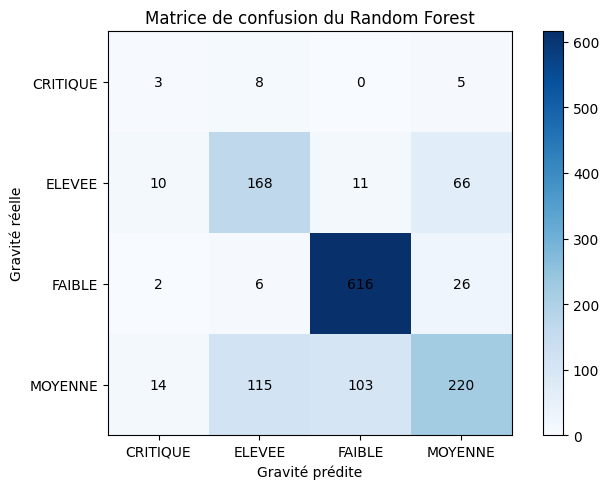

In [48]:
figure, axes = plt.subplots(figsize=(7, 5))
image = axes.imshow(matrice_confusion_finale.to_numpy(), cmap="Blues")
axes.set_xticks(range(len(matrice_confusion_finale.columns)))
axes.set_xticklabels(
    [colonne.replace("predit_", "") for colonne in matrice_confusion_finale.columns]
)
axes.set_yticks(range(len(matrice_confusion_finale.index)))
axes.set_yticklabels(
    [ligne.replace("reel_", "") for ligne in matrice_confusion_finale.index]
)
axes.set_xlabel("Gravité prédite")
axes.set_ylabel("Gravité réelle")
axes.set_title("Matrice de confusion du Random Forest")
for ligne in range(matrice_confusion_finale.shape[0]):
    for colonne in range(matrice_confusion_finale.shape[1]):
        axes.text(
            colonne,
            ligne,
            matrice_confusion_finale.iloc[ligne, colonne],
            ha="center",
            va="center",
        )
figure.colorbar(image, ax=axes)
plt.tight_layout()
plt.show()

La diagonale contient les bonnes prédictions. Les autres cellules représentent
les confusions. La classe `CRITIQUE` doit être interprétée avec prudence, car
elle ne compte que 79 incidents dans le dataset complet.

## 12. Comprendre quelles variables influencent la forêt

L'importance mesure combien une variable a contribué aux décisions des arbres.
Elle aide à expliquer le modèle, mais ne démontre pas une relation causale.

In [49]:
pipeline_final = joblib.load(
    repertoire_resultats / "foret_aleatoire_incidents_ia.joblib"
)
preparation_finale = pipeline_final.named_steps["preparation"]
modele_final = pipeline_final.named_steps["modele"]

importance_variables = (
    pd.DataFrame(
        {
            "variable": preparation_finale.get_feature_names_out(),
            "importance": modele_final.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
importance_variables.head(15)

,variable,importance
0,nombres__longueur_titre,0.244366
1,categories__nom_source_arXiv,0.117588
2,categories__nom_source_AI Incident Database,0.092786
3,nombres__annee_survenue,0.064783
4,nombres__nombre_parties_lesees,0.061644
5,nombres__annee_publication,0.054569
6,nombres__nombre_deployeurs,0.053444
7,categories__categorie_SYSTEME_AUTONOME,0.050854
8,nombres__nombre_developpeurs,0.050812
9,nombres__nombre_etiquettes,0.045886


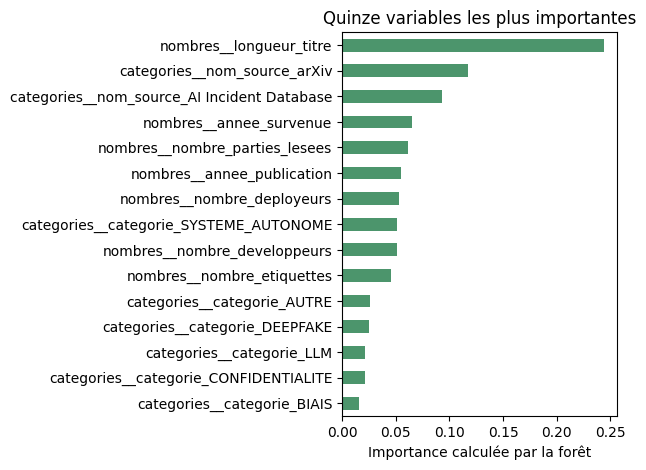

In [51]:
importance_variables.head(15).sort_values("importance").plot.barh(
    x="variable",
    y="importance",
    legend=False,
    color="#4c956c",
    title="Quinze variables les plus importantes",
)
plt.xlabel("Importance calculée par la forêt")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 13. Montrer un exemple de prédiction

Le pipeline applique automatiquement les mêmes transformations à une nouvelle
observation, puis les 200 arbres votent. Les probabilités correspondent à la
proportion de vote associée à chaque gravité.

In [50]:
exemple = donnees_preparees_eda.drop(columns=CIBLE).iloc[[0]]
gravite_reelle = donnees_preparees_eda[CIBLE].iloc[0]
gravite_predite = pipeline_final.predict(exemple)[0]
probabilites = pd.Series(
    pipeline_final.predict_proba(exemple)[0],
    index=pipeline_final.classes_,
    name="probabilite",
).sort_values(ascending=False)

print(f"Gravité réelle : {gravite_reelle}")
print(f"Gravité prédite : {gravite_predite}")
probabilites.to_frame()

Gravité réelle : FAIBLE
Gravité prédite : FAIBLE


,probabilite
FAIBLE,0.677335
MOYENNE,0.280399
ELEVEE,0.039920
CRITIQUE,0.002346


## 14. Limites à présenter

- Le dataset est déséquilibré, avec seulement 79 incidents `CRITIQUE`.
- La traduction automatique peut introduire quelques formulations imparfaites.
- Le modèle utilise la longueur du titre, mais ne comprend pas le sens du texte.
- Le nom de la source peut créer un biais lié aux habitudes de publication.
- Compter les acteurs supprime leur identité et simplifie fortement l'information.
- Une importance de variable décrit une association statistique, pas une cause.
- Le résultat dépend de la qualité des étiquettes de gravité du dataset.

## 15. Conclusion
1. L'EDA a montré un déséquilibre important de la cible.
2. Le feature engineering a transformé dates, textes et listes en variables
   compatibles avec un modèle classique.
3. La comparaison avec le modèle naïf vérifie que la forêt apprend réellement.
4. La comparaison avec et sans variables créées mesure leur apport.
5. Le pipeline garantit les mêmes transformations à l'entraînement et en
   prédiction.
6. La macro-F1 et la matrice de confusion évitent de masquer les difficultés
   rencontrées sur les classes rares.